In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from textProcessing import textProcessing
import nltk
from nltk.tokenize import TweetTokenizer
from nltk.corpus import stopwords
import string
from collections import Counter
import pyLDAvis
import pyLDAvis.lda_model
from wordcloud import WordCloud
from textProcessing import vaderAnalysis

from sklearn.feature_extraction.text import CountVectorizer, ENGLISH_STOP_WORDS
from sklearn.decomposition import LatentDirichletAllocation

[nltk_data] Downloading package vader_lexicon to
[nltk_data]     C:\Users\callu\AppData\Roaming\nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!


In [2]:
df = pd.read_csv("housing_crisis_nlp_data.csv")
display(df)

,Video_ID,User,Text,Date,Likes,Is_Reply
0,vWlh41jJ2Ww,@davidwalden2887,The housing shortage in Australia will be imme...,2026-05-16T13:44:12Z,0,False
1,vWlh41jJ2Ww,@ColdPatterns,My last neighbour was a single 65 year old guy...,2026-02-22T17:48:56Z,0,False
2,vWlh41jJ2Ww,@StephP2025,We should all go back to where we came from. S...,2026-01-30T14:50:16Z,0,False
3,vWlh41jJ2Ww,@bull13__x,Bitcoin fixes this,2026-01-15T21:23:02Z,0,False
4,vWlh41jJ2Ww,@joebullwinkle5099,The systemic failure in housing is that the is...,2026-01-01T19:46:16Z,0,False
...,...,...,...,...,...,...
21071,RJDVeLa7uXg,@U.s.e.r.3493,Immigrants arent the majority buying houses......,2026-03-26T07:21:58Z,0,True
21072,RJDVeLa7uXg,@offcut7167,Australia has a lot of resources and big oppor...,2026-03-26T08:31:58Z,0,True
21073,RJDVeLa7uXg,@U.s.e.r.3493,​@offcut7167ah so you're saying that even if w...,2026-03-26T09:15:35Z,1,True
21074,RJDVeLa7uXg,@offcut7167,​​@U.s.e.r.3493Yeah two tiered society. The ol...,2026-03-26T09:27:48Z,2,True


In [3]:
tweetTokenizer = TweetTokenizer()
lPunct = list(string.punctuation)
lStopwords = stopwords.words('english') + lPunct + ['rt', 'via', '...', '…', '"', "'", '`', '’', '”', '—', '°', '“', '..', ':', '::']
processor = textProcessing(tweetTokenizer, lStopwords)
df['Text'] = df['Text'].fillna('').astype(str)
df['processedTokens'] = df['Text'].apply(processor.processText)
df['halfProcessedTokens'] = df['Text'].apply(processor.halfPreprocessText)

preUniqueWords = processor.returnUniqueWords(df, 'halfProcessedTokens')
postUniqueWords = processor.returnUniqueWords(df, 'processedTokens')
print(preUniqueWords.most_common(20))
print(postUniqueWords.most_common(20))

[('.', 38295), ('the', 30809), (',', 23847), ('to', 21999), ('and', 18044), ('a', 16288), ('of', 13235), ('is', 12517), ('in', 12197), ('for', 8364), ('that', 7323), ('are', 7220), ('it', 6678), ('I', 6644), ('you', 6295), ('have', 5269), ('on', 5026), ('they', 4955), ('’', 4869), ('be', 4798)]
[('people', 4658), ('housing', 4288), ('government', 3032), ('house', 2802), ('australia', 2542), ('would', 2461), ('prices', 2218), ('like', 2210), ('get', 2113), ('property', 2049), ('home', 1882), ('immigration', 1853), ('one', 1837), ('money', 1797), ('years', 1692), ('houses', 1691), ('need', 1584), ('tax', 1569), ('going', 1489), ('buy', 1460)]


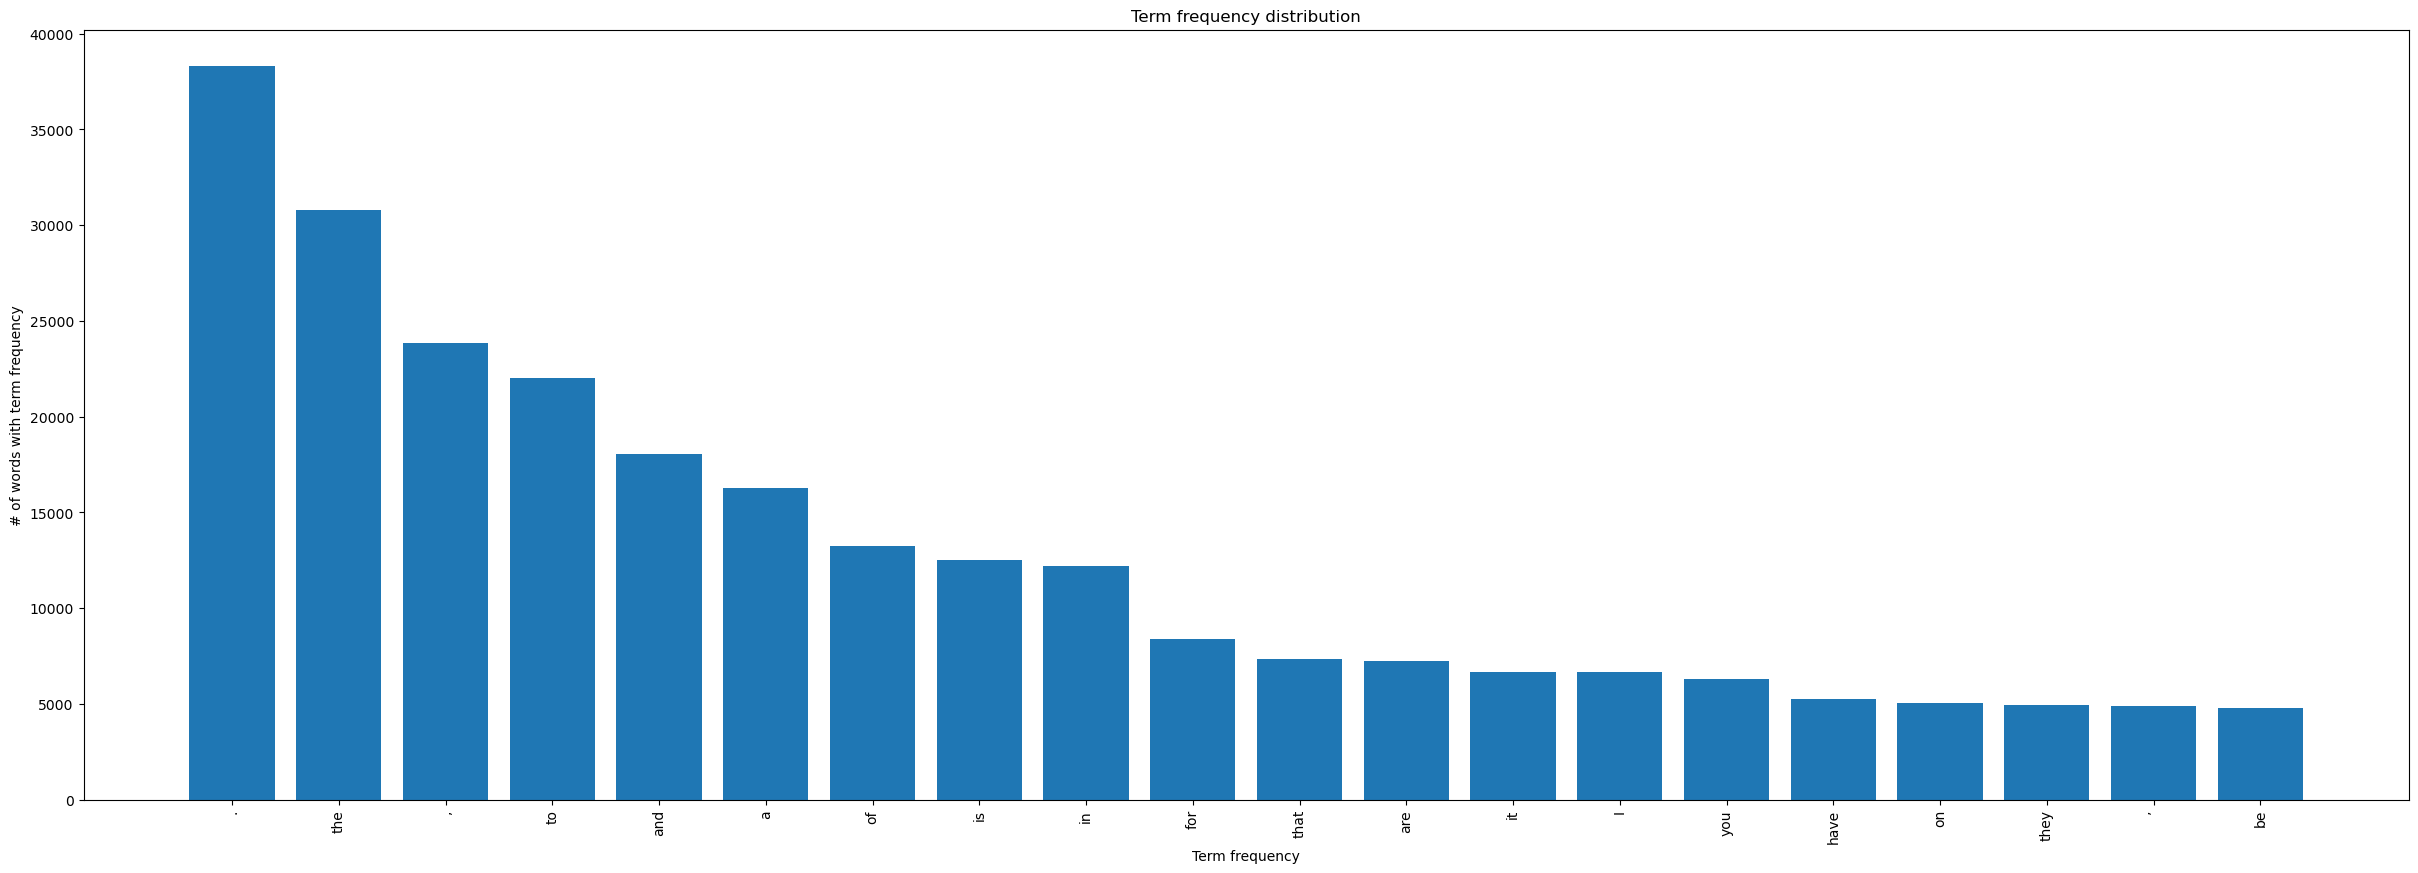

In [4]:

processor.outputGraphWordFreq(preUniqueWords, 20)

Word frequency before processing

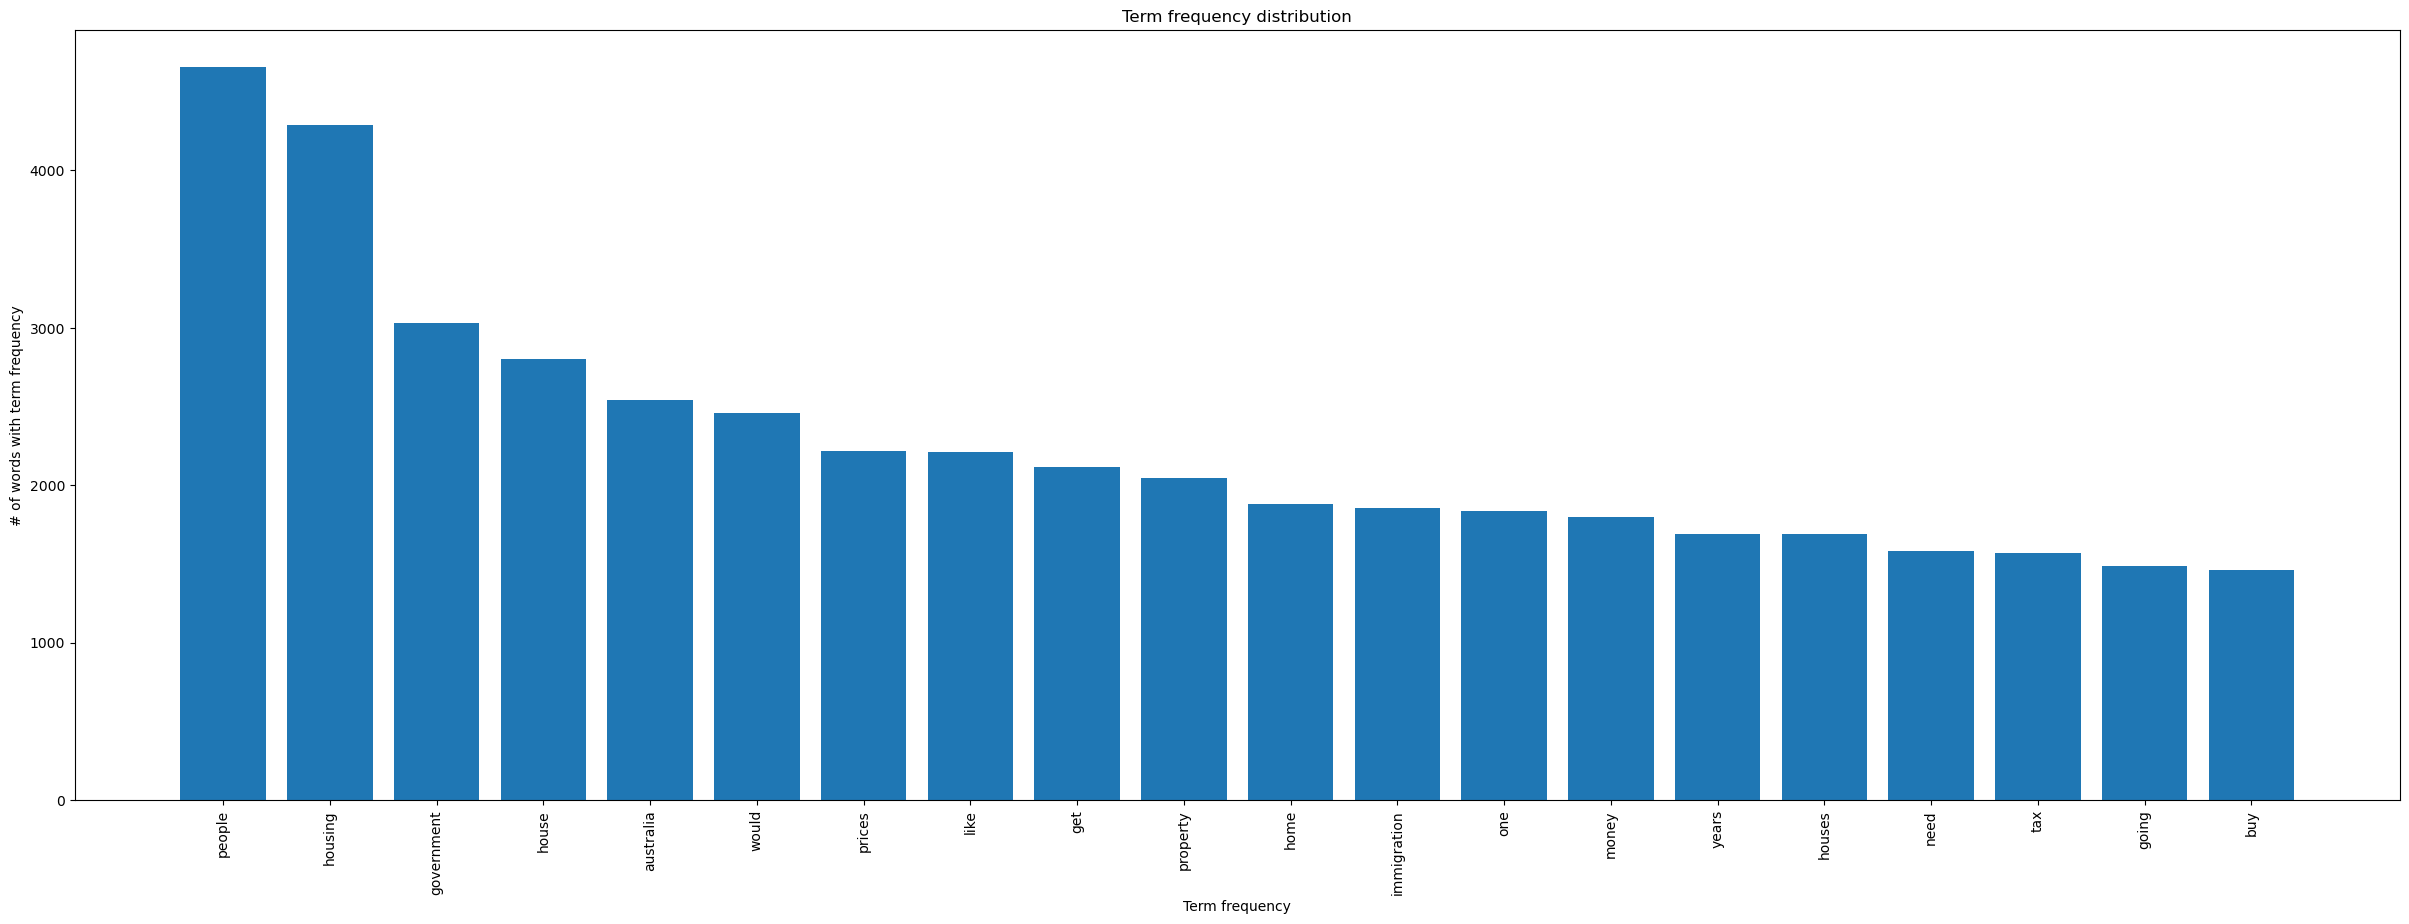

In [5]:
processor.outputGraphWordFreq(postUniqueWords, 20)

Word frequency after processing

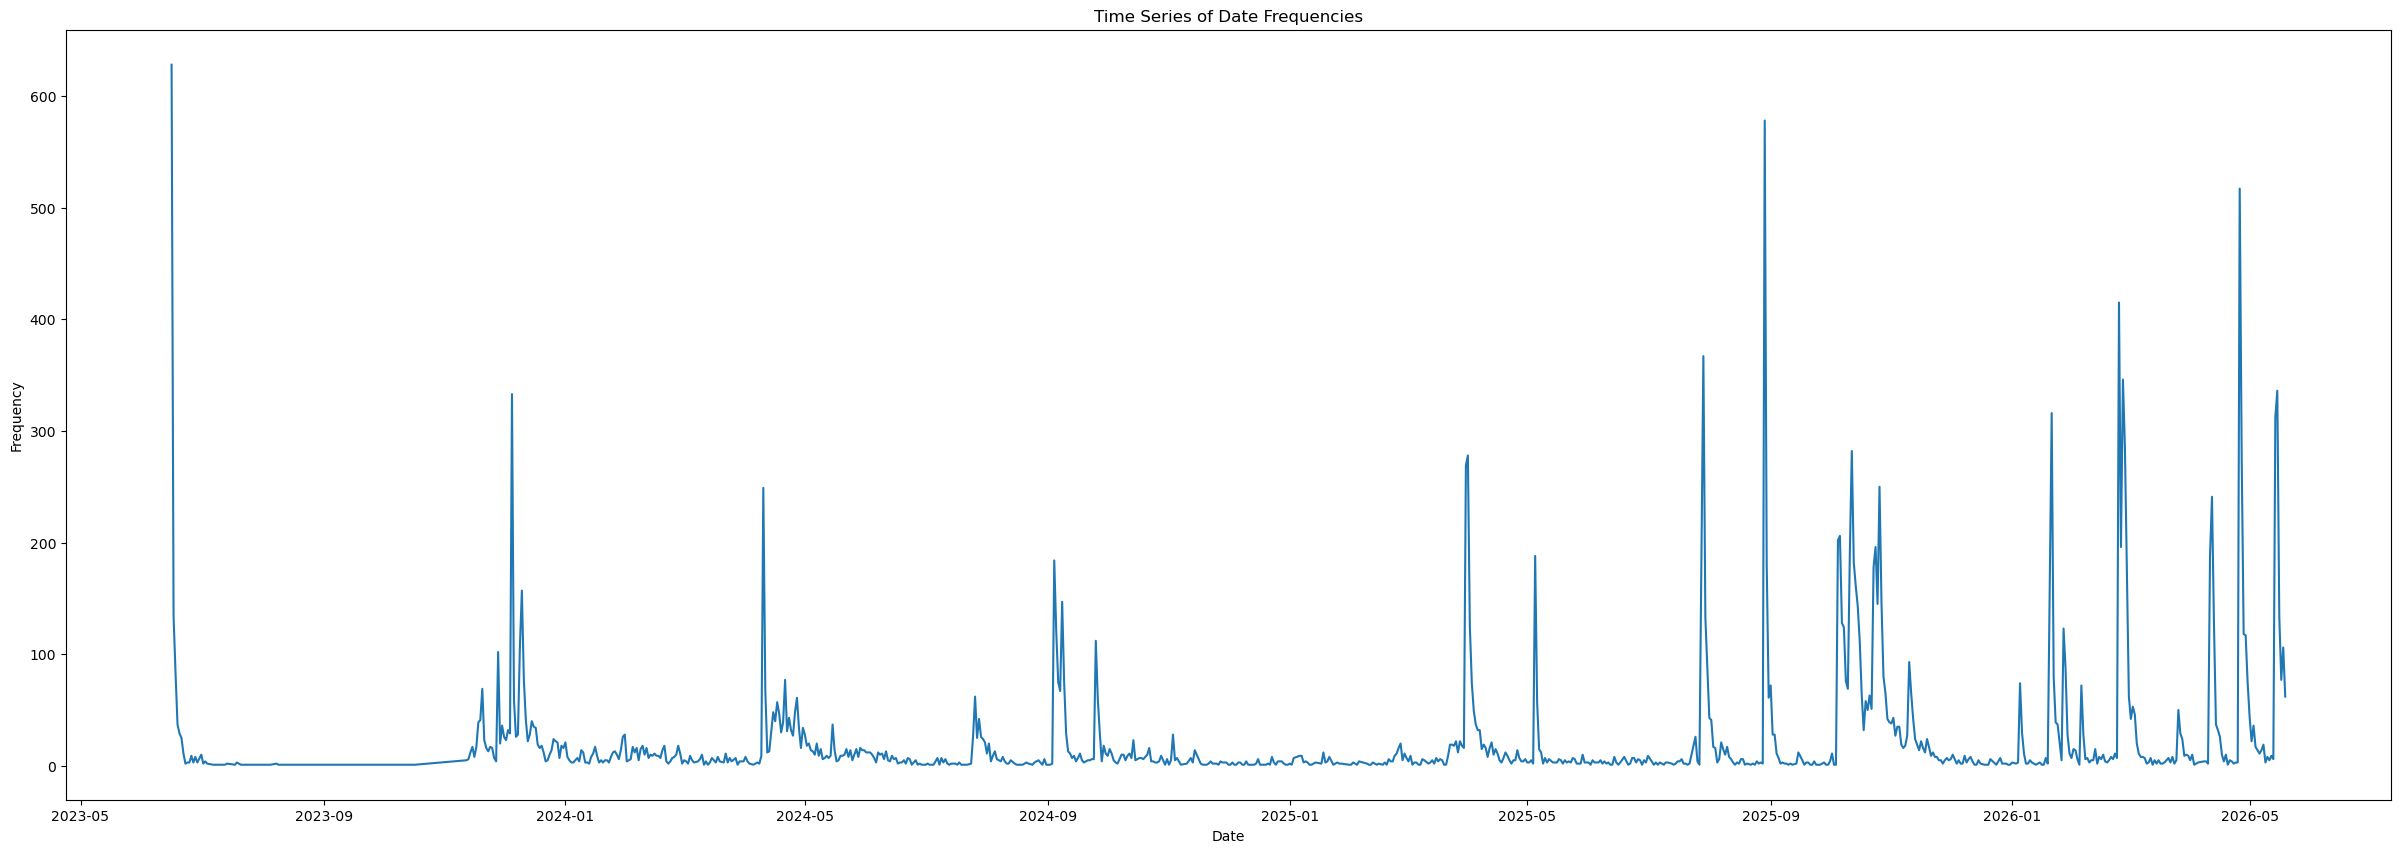

In [6]:
processor.outputGraphTimeSeries(df)

Time series graph of comments

In [7]:
dfAnalysed = pd.read_csv("housing_crisis_nlp_analysed.csv")
display(dfAnalysed)



,Video_ID,User,Text,Date,Likes,Is_Reply,Topic_Cluster,Predominant_Emotion
0,vWlh41jJ2Ww,@davidwalden2887,The housing shortage in Australia will be imme...,2026-05-16T13:44:12Z,0,False,-1,neutral
1,vWlh41jJ2Ww,@ColdPatterns,My last neighbour was a single 65 year old guy...,2026-02-22T17:48:56Z,0,False,-1,neutral
2,vWlh41jJ2Ww,@StephP2025,We should all go back to where we came from. S...,2026-01-30T14:50:16Z,0,False,-1,neutral
3,vWlh41jJ2Ww,@bull13__x,Bitcoin fixes this,2026-01-15T21:23:02Z,0,False,-1,neutral
4,vWlh41jJ2Ww,@joebullwinkle5099,The systemic failure in housing is that the is...,2026-01-01T19:46:16Z,0,False,8,neutral
...,...,...,...,...,...,...,...,...
21069,RJDVeLa7uXg,@U.s.e.r.3493,Immigrants arent the majority buying houses......,2026-03-26T07:21:58Z,0,True,2,neutral
21070,RJDVeLa7uXg,@offcut7167,Australia has a lot of resources and big oppor...,2026-03-26T08:31:58Z,0,True,-1,neutral
21071,RJDVeLa7uXg,@U.s.e.r.3493,​@offcut7167ah so you're saying that even if w...,2026-03-26T09:15:35Z,1,True,145,neutral
21072,RJDVeLa7uXg,@offcut7167,​​@U.s.e.r.3493Yeah two tiered society. The ol...,2026-03-26T09:27:48Z,2,True,-1,neutral


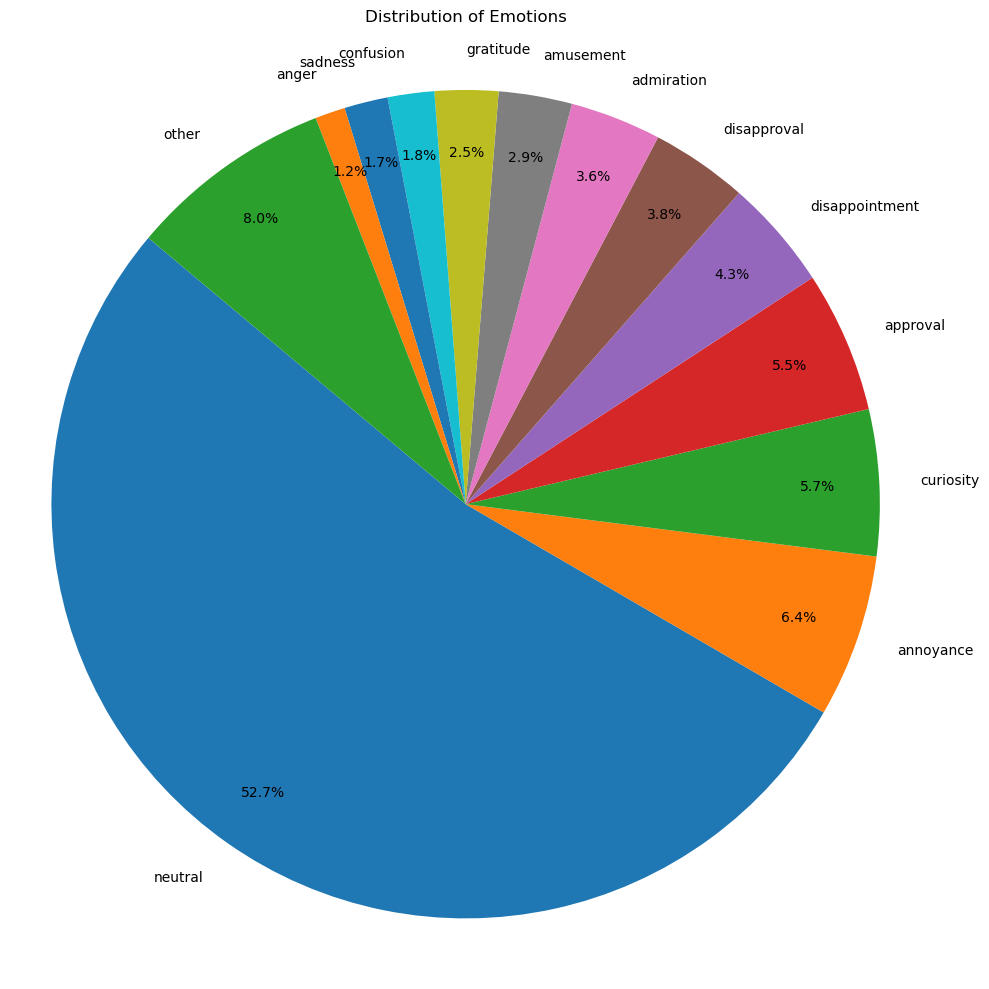

In [8]:
processor.outputGraphEmotionPieChart(dfAnalysed, 12)

Emotions/Sentiment analysis of comments

In [9]:
communities = pd.read_csv("video_community_analysis.csv")
communityArr = []

for _, row in communities.iterrows():
    currIds = row['Videos']
    communityArr.append([row['Community_ID'], currIds.split('; ')])
    

In [10]:
def getCommunity(Video_ID, communityArr):
    for commId, vids in communityArr:
        if Video_ID in vids:
            return commId
    return -1
    
dfAnalysed['Community_ID'] = dfAnalysed['Video_ID'].apply(lambda vid: getCommunity(vid, communityArr))
comm0 = dfAnalysed[dfAnalysed['Community_ID'] == 0]
comm1 = dfAnalysed[dfAnalysed['Community_ID'] == 1]
comm2 = dfAnalysed[dfAnalysed['Community_ID'] == 2]

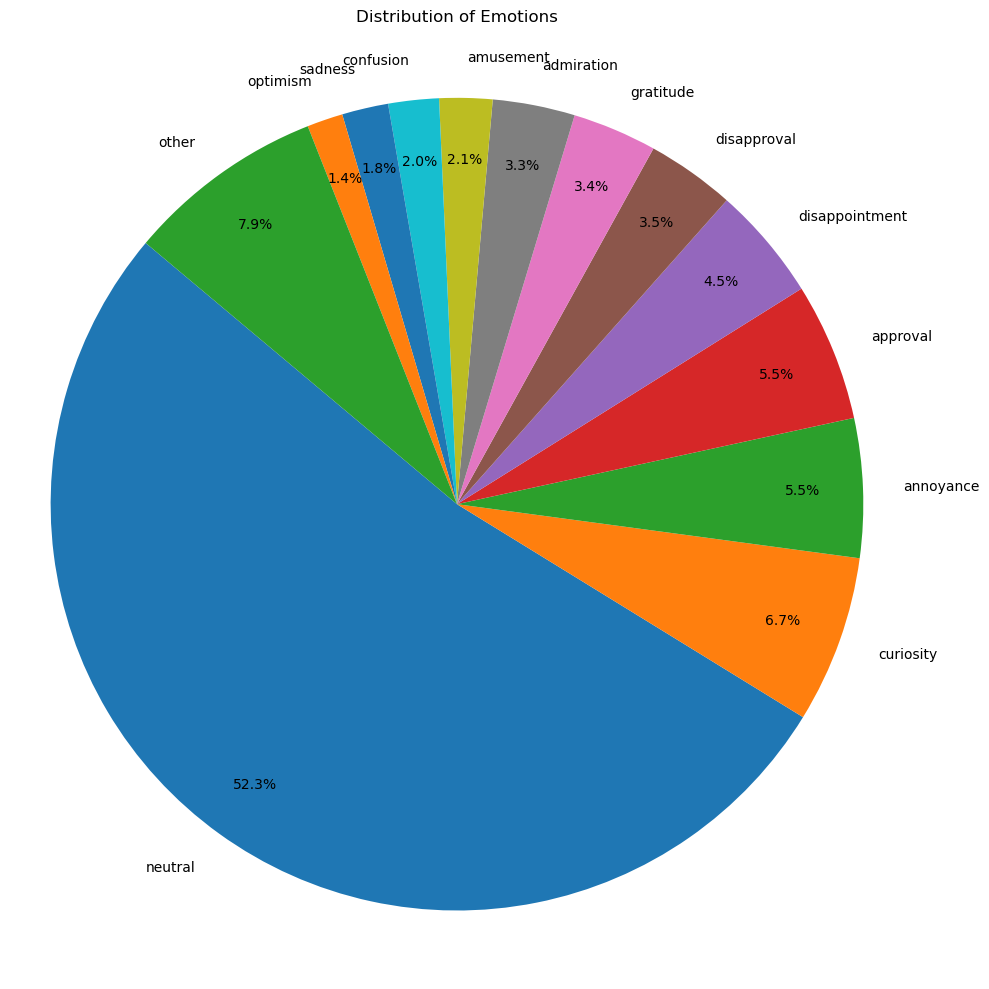

In [11]:
processor.outputGraphEmotionPieChart(comm0, 12)

Community zero sentiment analysis

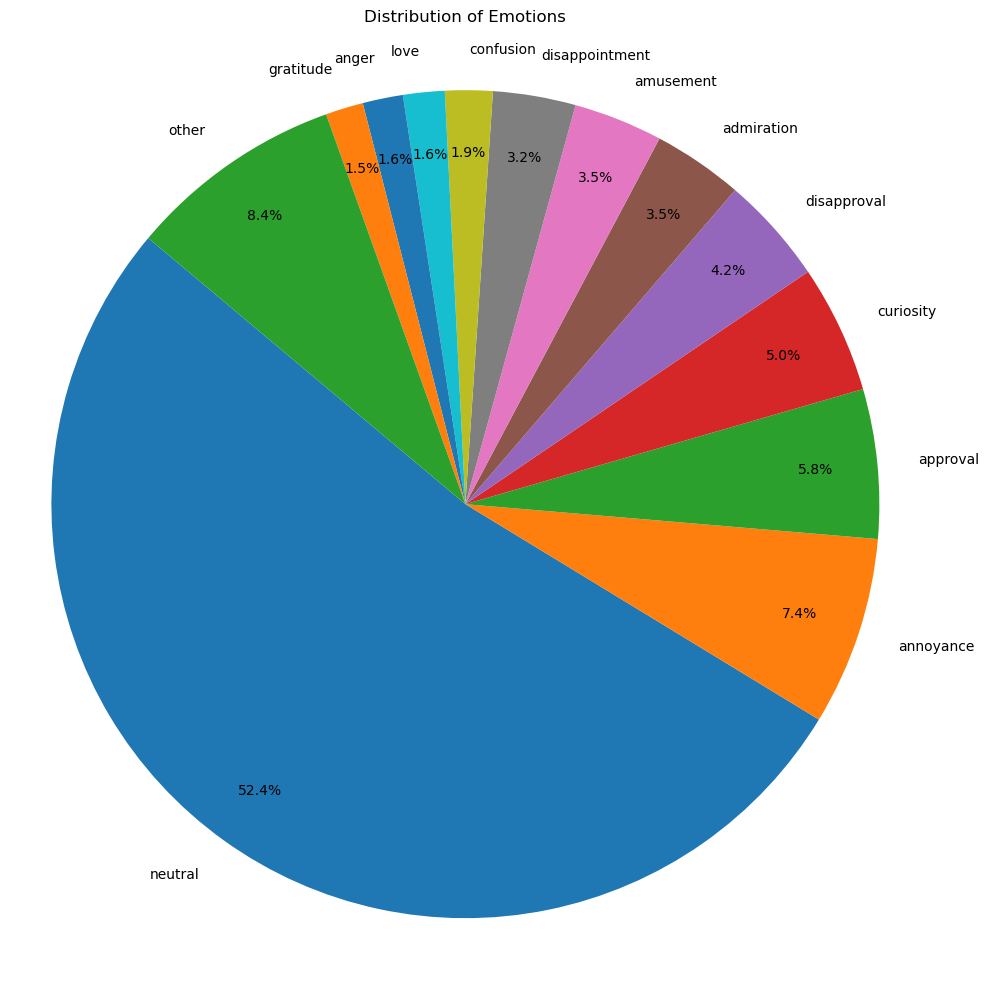

In [12]:
processor.outputGraphEmotionPieChart(comm1, 12)

community 1 sentiment analysis

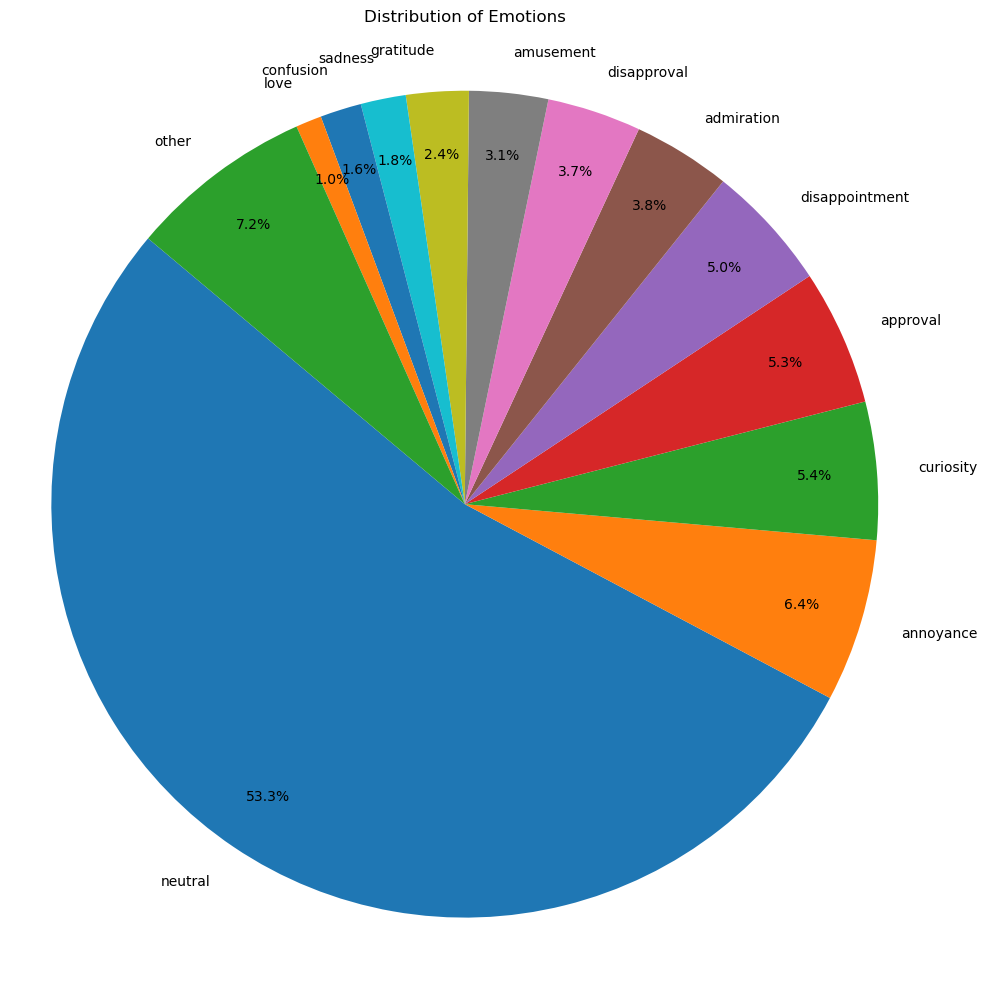

In [13]:
processor.outputGraphEmotionPieChart(comm2, 12)

community 2 sentiment analysis

Topic 1:
australia labor immigration government country housing people world greens australian video stop problem crisis immigrants australians party vote like politicians
Topic 2:
people like house live want work years going need home buy rent right good living way afford time know money
Topic 3:
housing prices property tax government market houses land house money investment home homes supply build properties demand new investors high


c:\Users\callu\anaconda3\Lib\site-packages\sklearn\manifold\_mds.py:677: FutureWarning: The default value of `n_init` will change from 4 to 1 in 1.9.
  warnings.warn(


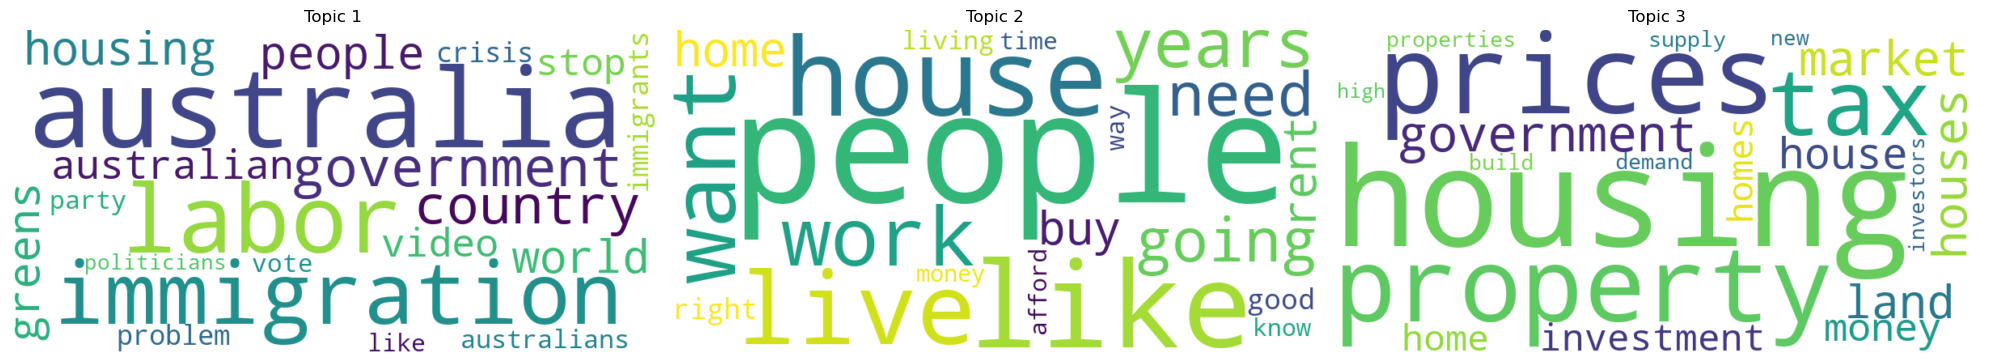

In [14]:
ldaModel, tf = processor.getLDAModel(df, 3, 20, 1500)

Generates code and LDA visulisation html file

In [15]:
df['Community_ID'] = df['Video_ID'].apply(lambda vid: getCommunity(vid, communityArr))
comm0 = df[df['Community_ID'] == 0]
comm1 = df[df['Community_ID'] == 1]
comm2 = df[df['Community_ID'] == 2]



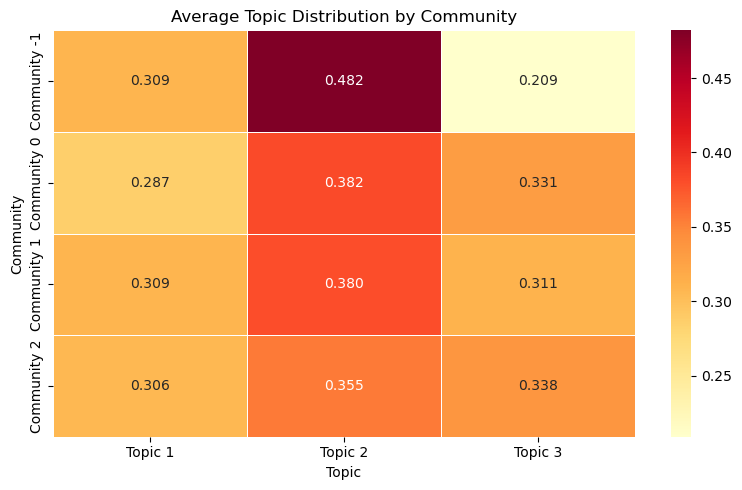

In [16]:
import seaborn as sns

# Get per-document topic distributions (n_docs × n_topics)
docTopicMatrix = ldaModel.transform(tf)

topicCols = [f'Topic {i+1}' for i in range(docTopicMatrix.shape[1])]
docTopicDf = pd.DataFrame(docTopicMatrix, columns=topicCols, index=df.index)
docTopicDf['Community_ID'] = df['Community_ID'].values

# Average topic weight per community
communityTopicMeans = docTopicDf.groupby('Community_ID')[topicCols].mean()
communityTopicMeans.index = [f'Community {c}' for c in communityTopicMeans.index]

plt.figure(figsize=(8, 5))
sns.heatmap(communityTopicMeans, annot=True, fmt='.3f', cmap='YlOrRd', linewidths=0.5)
plt.title('Average Topic Distribution by Community')
plt.ylabel('Community')
plt.xlabel('Topic')
plt.tight_layout()
plt.show()

In [17]:
VADERanalyzer = vaderAnalysis()

print(VADERanalyzer.AvgSentiment(df, 'Text'))


-0.006030660466881759


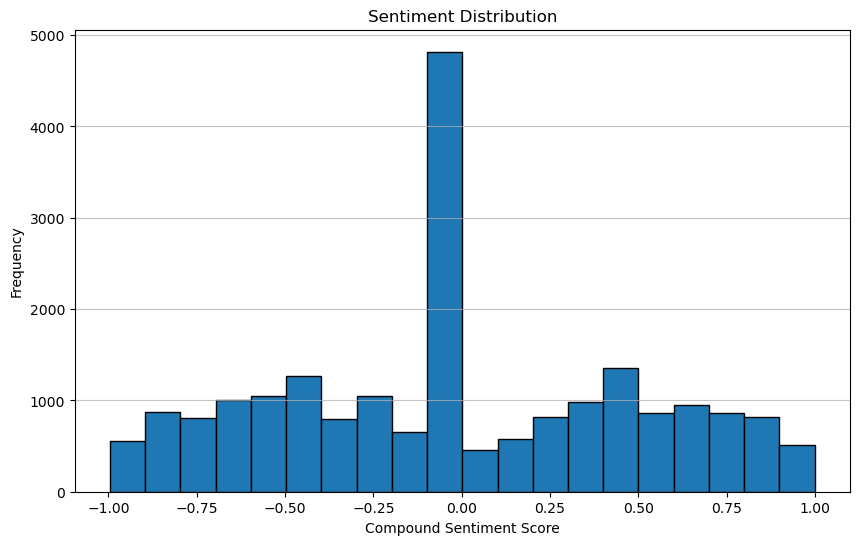

In [18]:

VADERanalyzer.graphSentimentDistribution(df, 'Text')

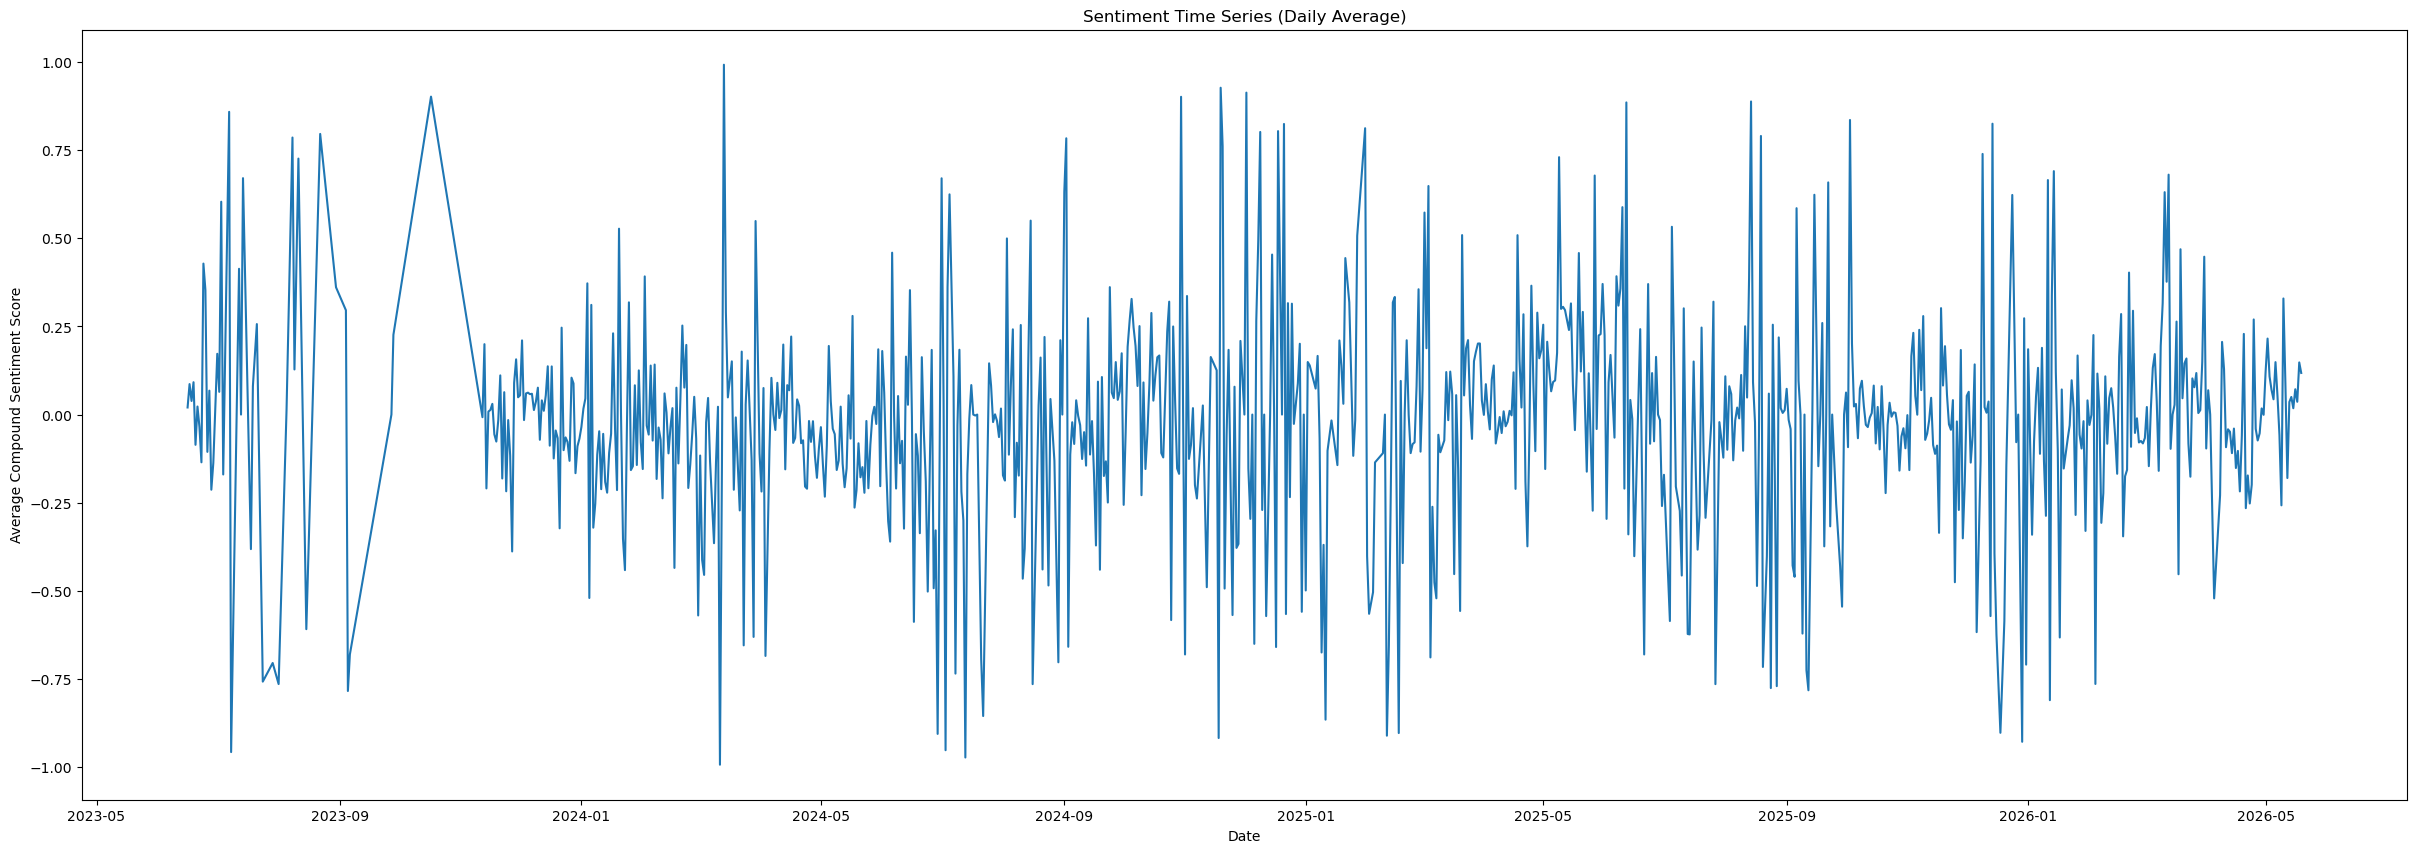

In [19]:
VADERanalyzer.sentimentTimeSeries(df, 'Text')

-0.016276708720366004


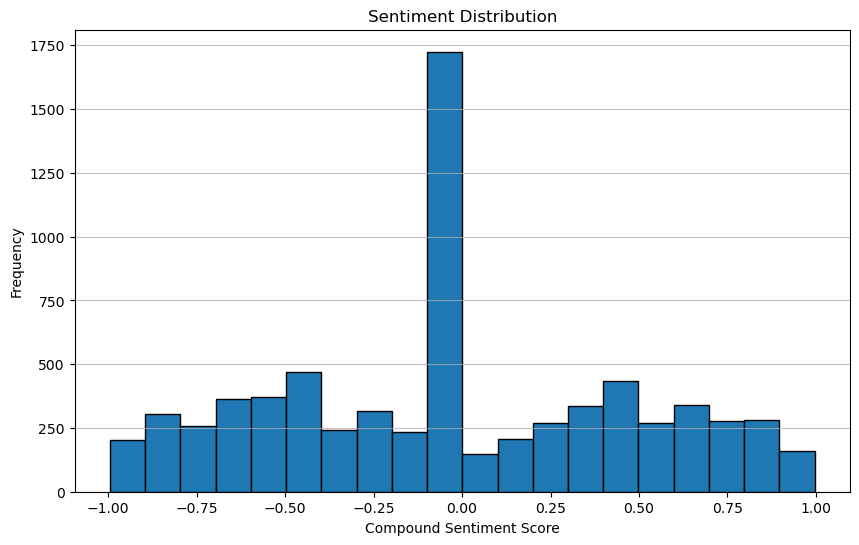

In [20]:
print(VADERanalyzer.AvgSentiment(comm0, 'Text'))
VADERanalyzer.graphSentimentDistribution(comm0, 'Text')

0.018888162251655627


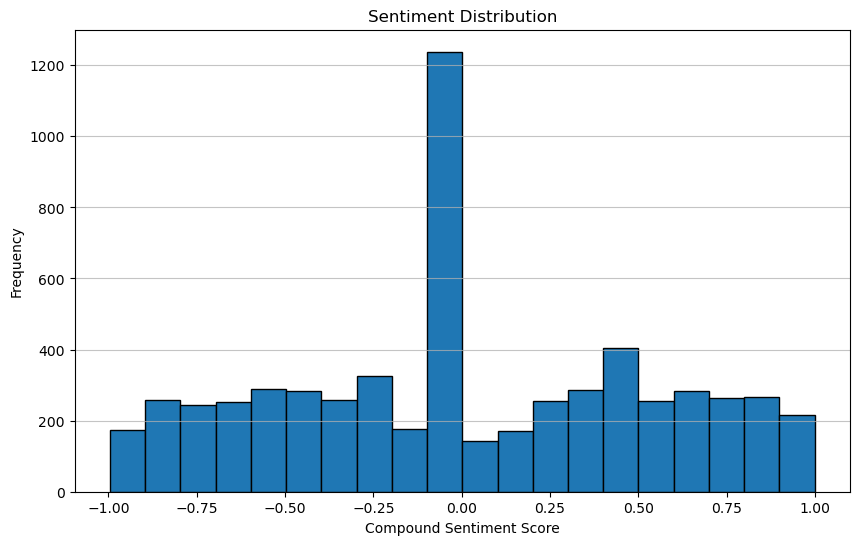

In [21]:
print(VADERanalyzer.AvgSentiment(comm1, 'Text'))
VADERanalyzer.graphSentimentDistribution(comm1, 'Text')

-0.015701330603889462


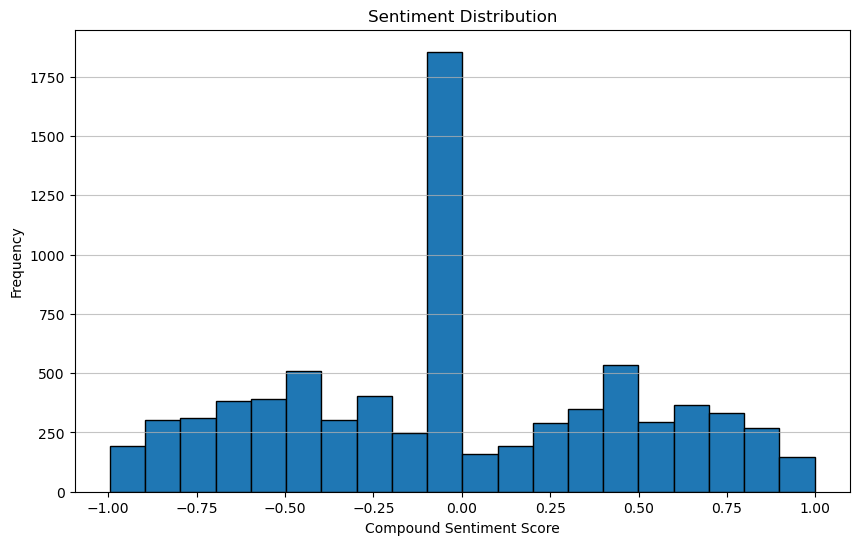

In [22]:
print(VADERanalyzer.AvgSentiment(comm2, 'Text'))
VADERanalyzer.graphSentimentDistribution(comm2, 'Text')

In [23]:
topNeg = VADERanalyzer.topNegativeComments(df, 'Text', 5)
topPos = VADERanalyzer.topPositiveComments(df, 'Text', 5)

In [24]:
print("Top 5 Negative Comments:")
for comment in topNeg:
    print(comment)

print("\nTop 5 Positive Comments:")
for  comment in topPos:
    print(comment)

Top 5 Negative Comments:
(-0.9957, 'bruh ketamine is one of the most important medicines ever made, its basically one of the only non-gas drugs that can be used similarly to gas anesthetics when putting people under in places with minimal infrastructure, like the third world or in emergency scenarios, even with gasses ket is still sometimes used as one of the anesthetics in surgery, it also is a heavily researched treatment for depression, and if you want to ban ket, then the third world might actually start doing surgery with fucking pcp again which is the drug that ket replaced.\n\nAlso the only differences in the effects between GHB and alcohol is basically the dosage curve, instead a few ml will get you to the same place several shots do, it acts on the same neurons, and has extremely similar reported effects. But you are right, GHB has little to no medical value, it does have value as a chemical solvent which is the reason it used to be found in Legos and other plastic items, and 

In [25]:
topNeg = VADERanalyzer.topNegativeComments(comm0, 'Text', 5)
topPos = VADERanalyzer.topPositiveComments(comm0, 'Text', 5)
print("Top 5 Negative Comments:")
for comment in topNeg:
    print(comment)

print("\nTop 5 Positive Comments:")
for  comment in topPos:
    print(comment)

Top 5 Negative Comments:
(-0.9949, 'I am sick of Albo! I am sick of Immigration, I am sick of pro- Palestine protests! I am sick of black- life matter! I am sick of pro Nazi- pro Communist - pro Islam - pro Liberal  ideology! I am sick of Climate Change and Global Warming! I am sick of OZONE Holes!  I am sick of Thirty third  Genders ! I am sick of Corona Virus Madness, I am sick of Inflation! I am sick of Housing Prices! I am sick of Rental crisis! I am sick of Faked Education! I am sick of too many clowns  in politics in Australia. I want to live in normal world!')
(-0.9949, 'I am sick of Albo! I am sick of Immigration, I am sick of pro- Palestine protests! I am sick of black- life matter! I am sick of pro Nazi- pro Communist - pro Islam - pro Liberal  ideology! I am sick of Climate Change and Global Warming! I am sick of OZONE Holes!  I am sick of Thirty third  Genders ! I am sick of Corona Virus Madness, I am sick of Inflation! I am sick of Housing Prices! I am sick of Rental crisi

In [26]:
topNeg = VADERanalyzer.topNegativeComments(comm1, 'Text', 5)
topPos = VADERanalyzer.topPositiveComments(comm1, 'Text', 5)
print("Top 5 Negative Comments:")
for comment in topNeg:
    print(comment)

print("\nTop 5 Positive Comments:")
for  comment in topPos:
    print(comment)

Top 5 Negative Comments:
(-0.9957, 'bruh ketamine is one of the most important medicines ever made, its basically one of the only non-gas drugs that can be used similarly to gas anesthetics when putting people under in places with minimal infrastructure, like the third world or in emergency scenarios, even with gasses ket is still sometimes used as one of the anesthetics in surgery, it also is a heavily researched treatment for depression, and if you want to ban ket, then the third world might actually start doing surgery with fucking pcp again which is the drug that ket replaced.\n\nAlso the only differences in the effects between GHB and alcohol is basically the dosage curve, instead a few ml will get you to the same place several shots do, it acts on the same neurons, and has extremely similar reported effects. But you are right, GHB has little to no medical value, it does have value as a chemical solvent which is the reason it used to be found in Legos and other plastic items, and 

In [27]:
topNeg = VADERanalyzer.topNegativeComments(comm2, 'Text', 5)
topPos = VADERanalyzer.topPositiveComments(comm2, 'Text', 5)
print("Top 5 Negative Comments:")
for comment in topNeg:
    print(comment)

print("\nTop 5 Positive Comments:")
for  comment in topPos:
    print(comment)

Top 5 Negative Comments:
(-0.9951, "@slow_rogan It doesn't matter which words I choose to use for them.  The issues are real & being blatantly ignored or purposely forced for whatever reason.\n The main problem with the housing crisis is immigration. Too many people and a lack of new builds. The second is the construction industry is a mess & cannot meet the demands of the current levels. Caused in no small part, but not entirely by immigration. No skills or ethics.\n* Too many immigrants. To much demand.\n* Terrible political policies. \n* Corruption. At all Government levels. Unions, Organised crime. Corporate crime & individuals.  \n* Greed & lack of ethics. Did I mention greed? Pure greed & so money-driven that it's like an aura around them. It is so prevalent. \n* Blatant disregard for following Australian standards & practices. \n* They absolutely don't care about the finished product, have no pride & the poor customer is left with a mess.\n* Too many unskilled imports who refuse

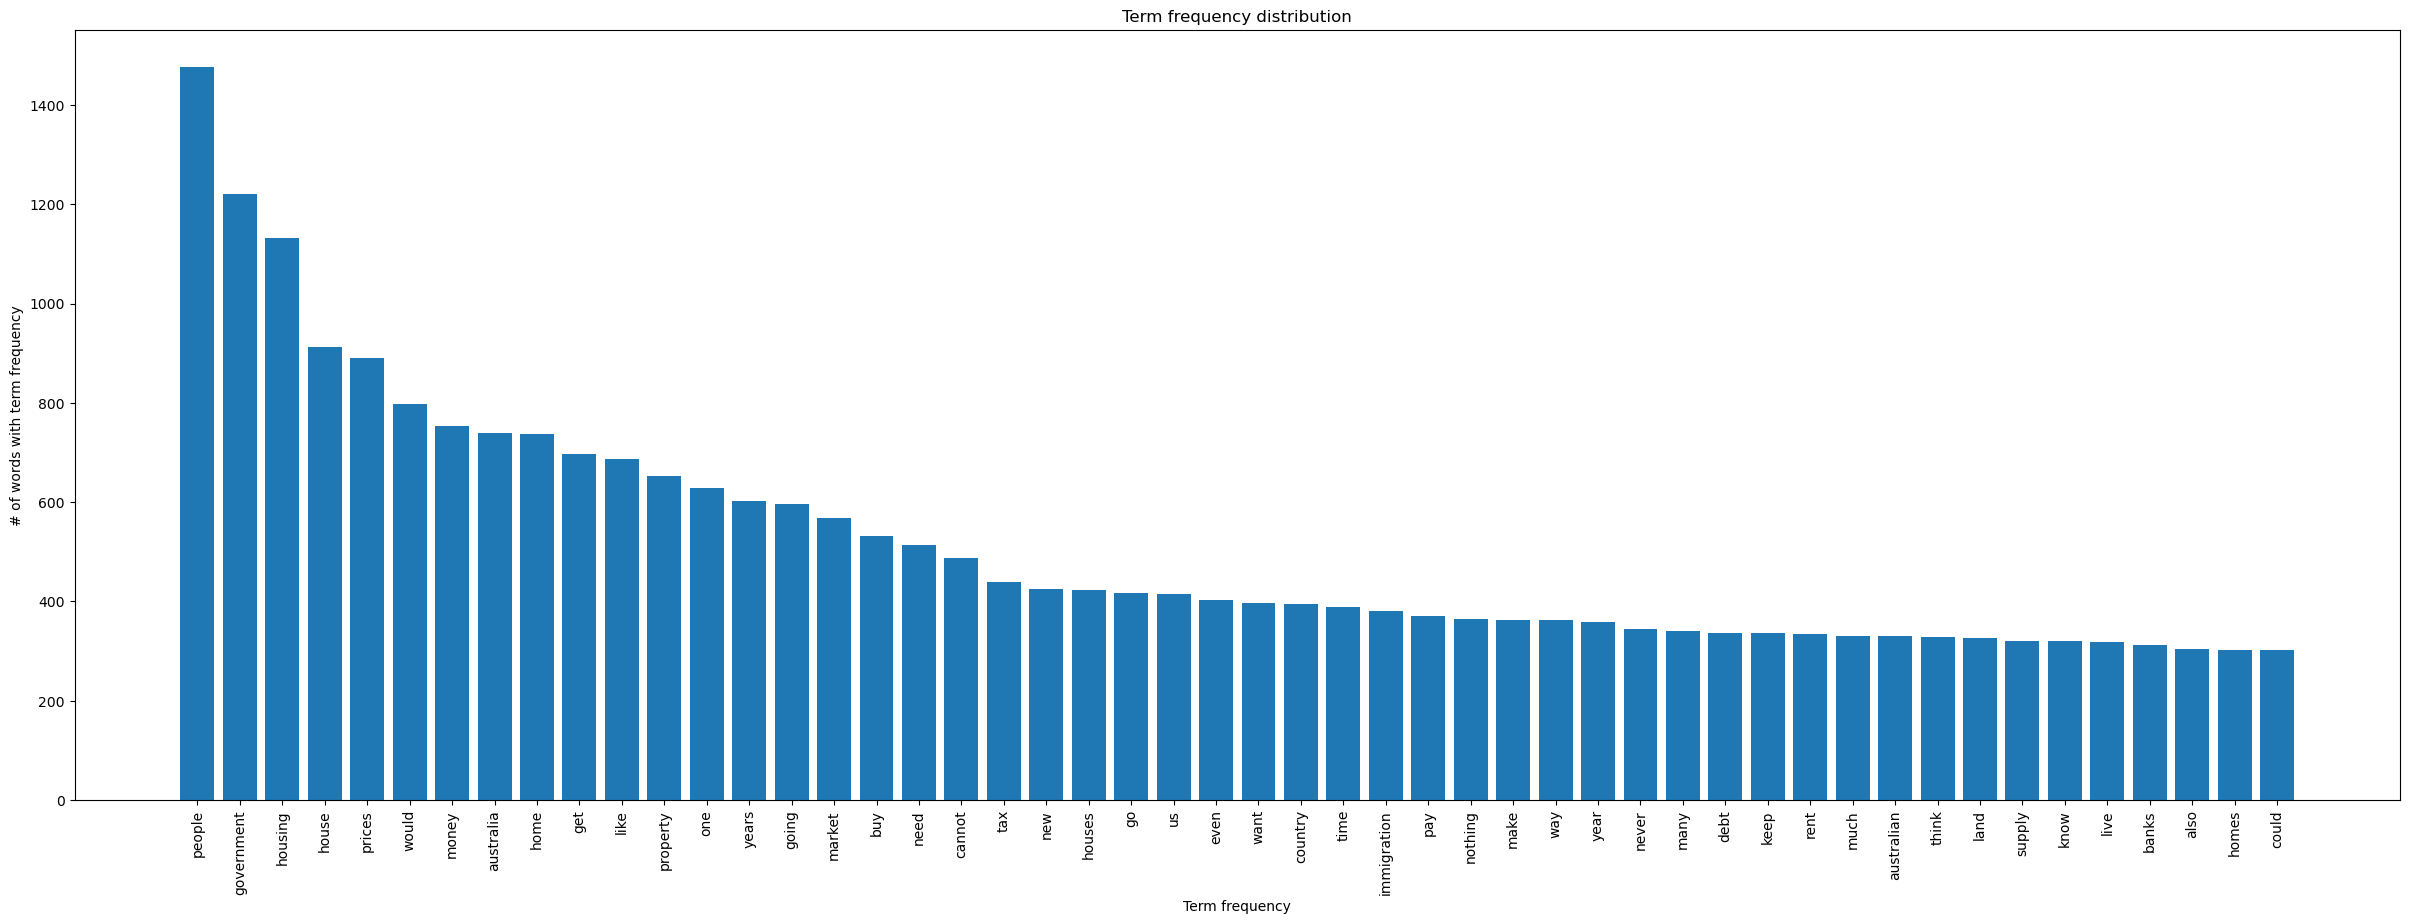

In [32]:
postUniqueWords = processor.returnUniqueWords(comm0, 'processedTokens')
processor.outputGraphWordFreq(postUniqueWords, 50)

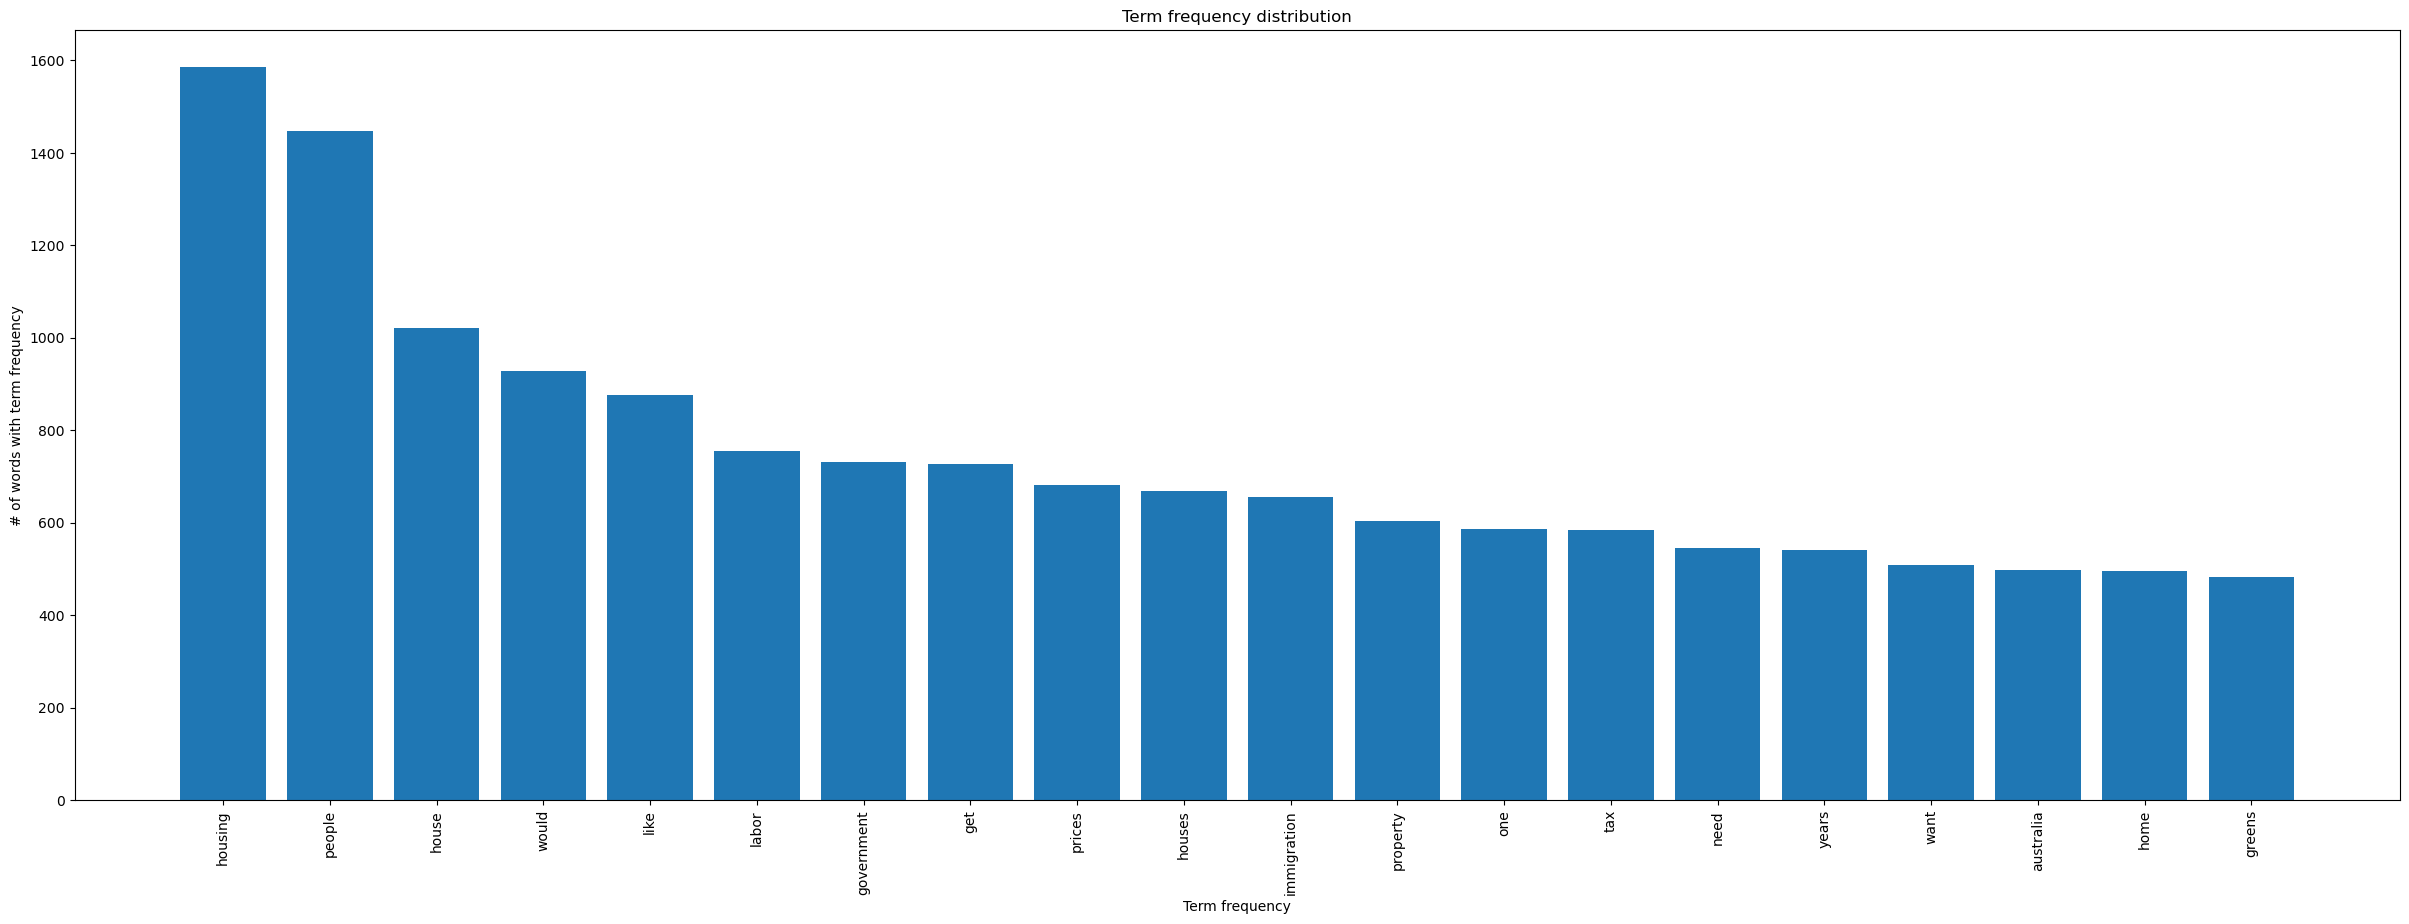

In [33]:
postUniqueWords = processor.returnUniqueWords(comm1, 'processedTokens')
processor.outputGraphWordFreq(postUniqueWords, 20)

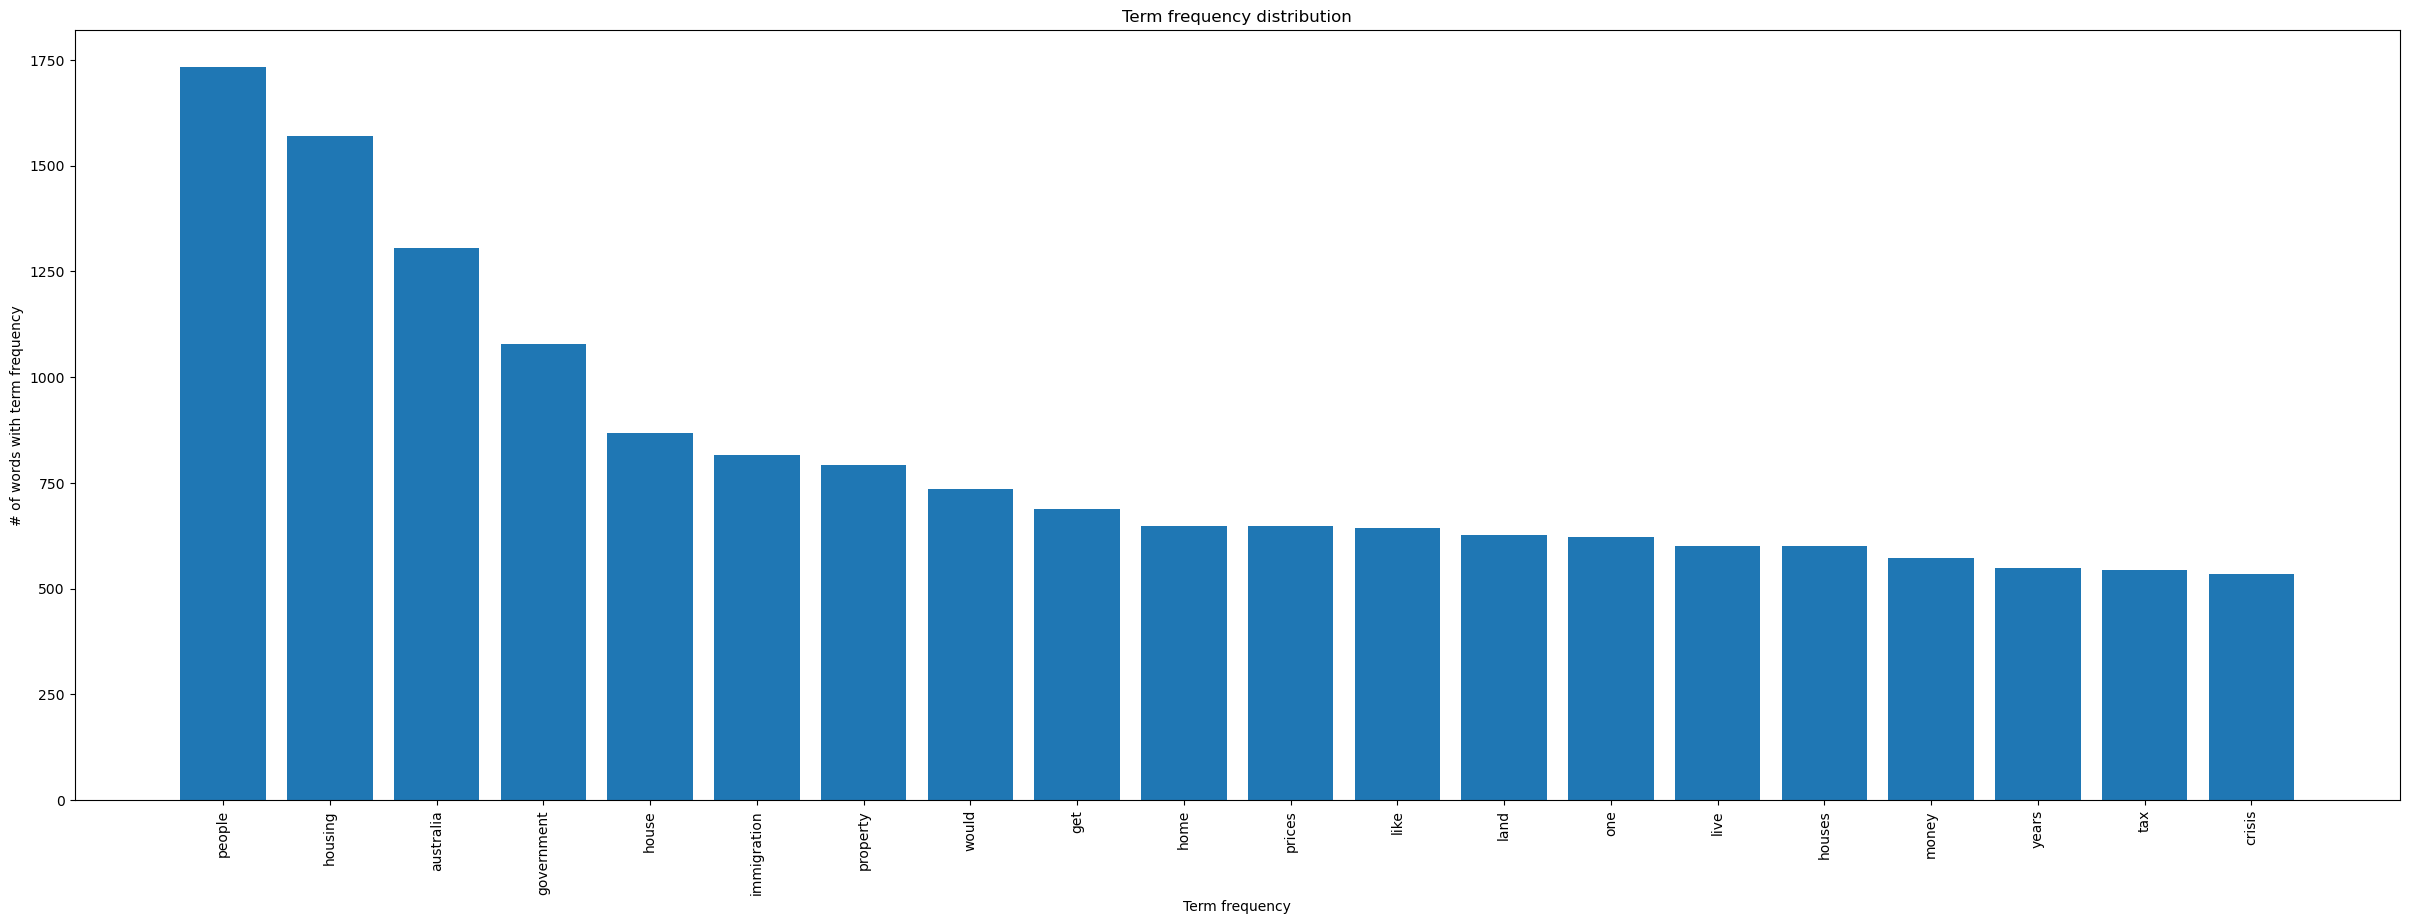

In [34]:
postUniqueWords = processor.returnUniqueWords(comm2, 'processedTokens')
processor.outputGraphWordFreq(postUniqueWords, 20)